## Comment

Although the task specified that we should use the Titanic dataset, I used the "Credit score classification" dataset from Kaggle, because it contains more continuous columns than the other one. This makes it easier to present the results of dimensionality reduction and clustering algorithms.

## Necessary Imports, Dataset Loading, Dataset Preprocessing

Imports...

In [83]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE, LocallyLinearEmbedding, MDS, Isomap
from sklearn.cluster import AgglomerativeClustering, KMeans, SpectralClustering, DBSCAN, OPTICS
from sklearn.metrics import silhouette_score, davies_bouldin_score

Loading the dataset and looking at it...

In [2]:
data = pd.read_csv("credit_card_dataset/train.csv")

/tmp/ipykernel_28973/591009048.py:1: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("credit_card_dataset/train.csv")


In [3]:
data

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x1602,CUS_0xd40,January,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,_,809.98,26.822620,22 Years and 1 Months,No,49.574949,80.41529543900253,High_spent_Small_value_payments,312.49408867943663,Good
1,0x1603,CUS_0xd40,February,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.944960,NaN,No,49.574949,118.28022162236736,Low_spent_Large_value_payments,284.62916249607184,Good
2,0x1604,CUS_0xd40,March,Aaron Maashoh,-500,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,28.609352,22 Years and 3 Months,No,49.574949,81.699521264648,Low_spent_Medium_value_payments,331.2098628537912,Good
3,0x1605,CUS_0xd40,April,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,NaN,3,...,Good,809.98,31.377862,22 Years and 4 Months,No,49.574949,199.4580743910713,Low_spent_Small_value_payments,223.45130972736786,Good
4,0x1606,CUS_0xd40,May,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,Good,809.98,24.797347,22 Years and 5 Months,No,49.574949,41.420153086217326,High_spent_Medium_value_payments,341.48923103222177,Good
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,0x25fe9,CUS_0x942c,April,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,_,502.38,34.663572,31 Years and 6 Months,No,35.104023,60.97133255718485,High_spent_Large_value_payments,479.866228,Poor
99996,0x25fea,CUS_0x942c,May,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,_,502.38,40.565631,31 Years and 7 Months,No,35.104023,54.18595028760385,High_spent_Medium_value_payments,496.65161,Poor
99997,0x25feb,CUS_0x942c,June,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,Good,502.38,41.255522,31 Years and 8 Months,No,35.104023,24.02847744864441,High_spent_Large_value_payments,516.809083,Poor
99998,0x25fec,CUS_0x942c,July,Nicks,25,078-73-5990,Mechanic,39628.99,3359.415833,4,...,Good,502.38,33.638208,31 Years and 9 Months,No,35.104023,251.67258219721603,Low_spent_Large_value_payments,319.164979,Standard


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   ID                        100000 non-null  object 
 1   Customer_ID               100000 non-null  object 
 2   Month                     100000 non-null  object 
 3   Name                      90015 non-null   object 
 4   Age                       100000 non-null  object 
 5   SSN                       100000 non-null  object 
 6   Occupation                100000 non-null  object 
 7   Annual_Income             100000 non-null  object 
 8   Monthly_Inhand_Salary     84998 non-null   float64
 9   Num_Bank_Accounts         100000 non-null  int64  
 10  Num_Credit_Card           100000 non-null  int64  
 11  Interest_Rate             100000 non-null  int64  
 12  Num_of_Loan               100000 non-null  object 
 13  Type_of_Loan              88592 non-null   ob

Filtering out non-continuous data columns...

In [5]:
data = data[[
    "Age", "Annual_Income", "Monthly_Inhand_Salary", 
    "Outstanding_Debt", "Credit_Utilization_Ratio", "Total_EMI_per_month", 
    "Amount_invested_monthly", "Monthly_Balance"
]]

Converting str values to floats, where possible...

In [6]:
def converter(value: str | float) -> float:

    if type(value) is float:
        return value

    value = list(filter(lambda x: len(x) != 0, value.split("_")))

    if len(value) != 1:
        return float("NaN")

    value = float(value[0])

    if value < 0:
        return float("NaN")

    return value

pd.options.mode.copy_on_write = True

data["Age"] = data["Age"].map(converter).astype(float)
data["Annual_Income"] = data["Annual_Income"].map(converter).astype(float)
data["Outstanding_Debt"] = data["Outstanding_Debt"].map(converter).astype(float)
data["Amount_invested_monthly"] = data["Amount_invested_monthly"].map(converter).astype(float)
data["Monthly_Balance"] = data["Monthly_Balance"].map(converter).astype(float)

Fill the NaN values with the column mean...

In [7]:
data["Monthly_Inhand_Salary"] = data["Monthly_Inhand_Salary"].fillna(data["Monthly_Inhand_Salary"].mean())

data["Age"] = data["Age"].fillna(data["Age"].mean())
data["Annual_Income"] = data["Annual_Income"].fillna(data["Annual_Income"].mean())
data["Outstanding_Debt"] = data["Outstanding_Debt"].fillna(data["Outstanding_Debt"].mean())
data["Amount_invested_monthly"] = data["Amount_invested_monthly"].fillna(data["Amount_invested_monthly"].mean())
data["Monthly_Balance"] = data["Monthly_Balance"].fillna(data["Monthly_Balance"].mean())

Describe the data using statistics...

In [8]:
data.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,100000.000000,1.000000e+05,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,116.108421,1.764157e+05,4194.170850,1426.220376,32.285173,1403.118217,637.412998,402.551258
std,683.811678,1.429618e+06,2935.176493,1155.129026,5.116875,8306.041270,1997.034517,212.628374
min,14.000000,7.005930e+03,303.645417,0.230000,20.000000,0.000000,0.000000,0.007760
25%,25.000000,1.945750e+04,1792.084167,566.072500,28.052567,30.306660,77.017414,270.913865
50%,34.000000,3.757861e+04,3852.736667,1166.155000,32.305784,69.249473,143.127915,338.672152
75%,42.000000,7.279092e+04,5371.525000,1945.962500,36.496663,161.224249,304.765600,467.670597
max,8698.000000,2.419806e+07,15204.633333,4998.070000,50.000000,82331.000000,10000.000000,1602.040519


Correct unrealistic age values...

In [9]:
realistic_age_mean = data["Age"][data["Age"] <= 100].mean()
data["Age"] = data["Age"].map(lambda x: realistic_age_mean if x > 100 else x)

Log-transform distributions...

In [10]:
data = np.log1p(data)

Normalize every column...

In [11]:
column_means = data.mean(axis=0)
column_stds = data.std(axis=0)
data = (data - column_means) / column_stds
data

,Age,Annual_Income,Monthly_Inhand_Salary,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
0,-0.930070,-0.760267,-0.777650,-0.138873,-1.068813,-0.091104,-0.591868,-0.238820
1,-0.930070,-0.760267,0.338631,-0.138873,0.011516,-0.091104,-0.288556,-0.415177
2,0.156773,-0.760267,0.338631,-0.138873,-0.670913,-0.091104,-0.579438,-0.128961
3,-0.930070,-0.760267,0.338631,-0.138873,-0.099486,-0.091104,0.123733,-0.871833
4,-0.930070,-0.760267,-0.777650,-0.138873,-1.551974,-0.091104,-1.109634,-0.071228
...,...,...,...,...,...,...,...,...
99995,-0.686914,-0.004638,0.040914,-0.579264,0.518419,-0.262794,-0.808596,0.571688
99996,-0.686914,-0.004638,0.040914,-0.579264,1.497452,-0.262794,-0.900694,0.636692
99997,-0.686914,-0.004638,0.040914,-0.579264,1.602689,-0.262794,-1.528657,0.711918
99998,-0.686914,-0.004638,0.040914,-0.579264,0.331922,-0.262794,0.307581,-0.198928


Take a look at the distributions of the data. Use only a subset...

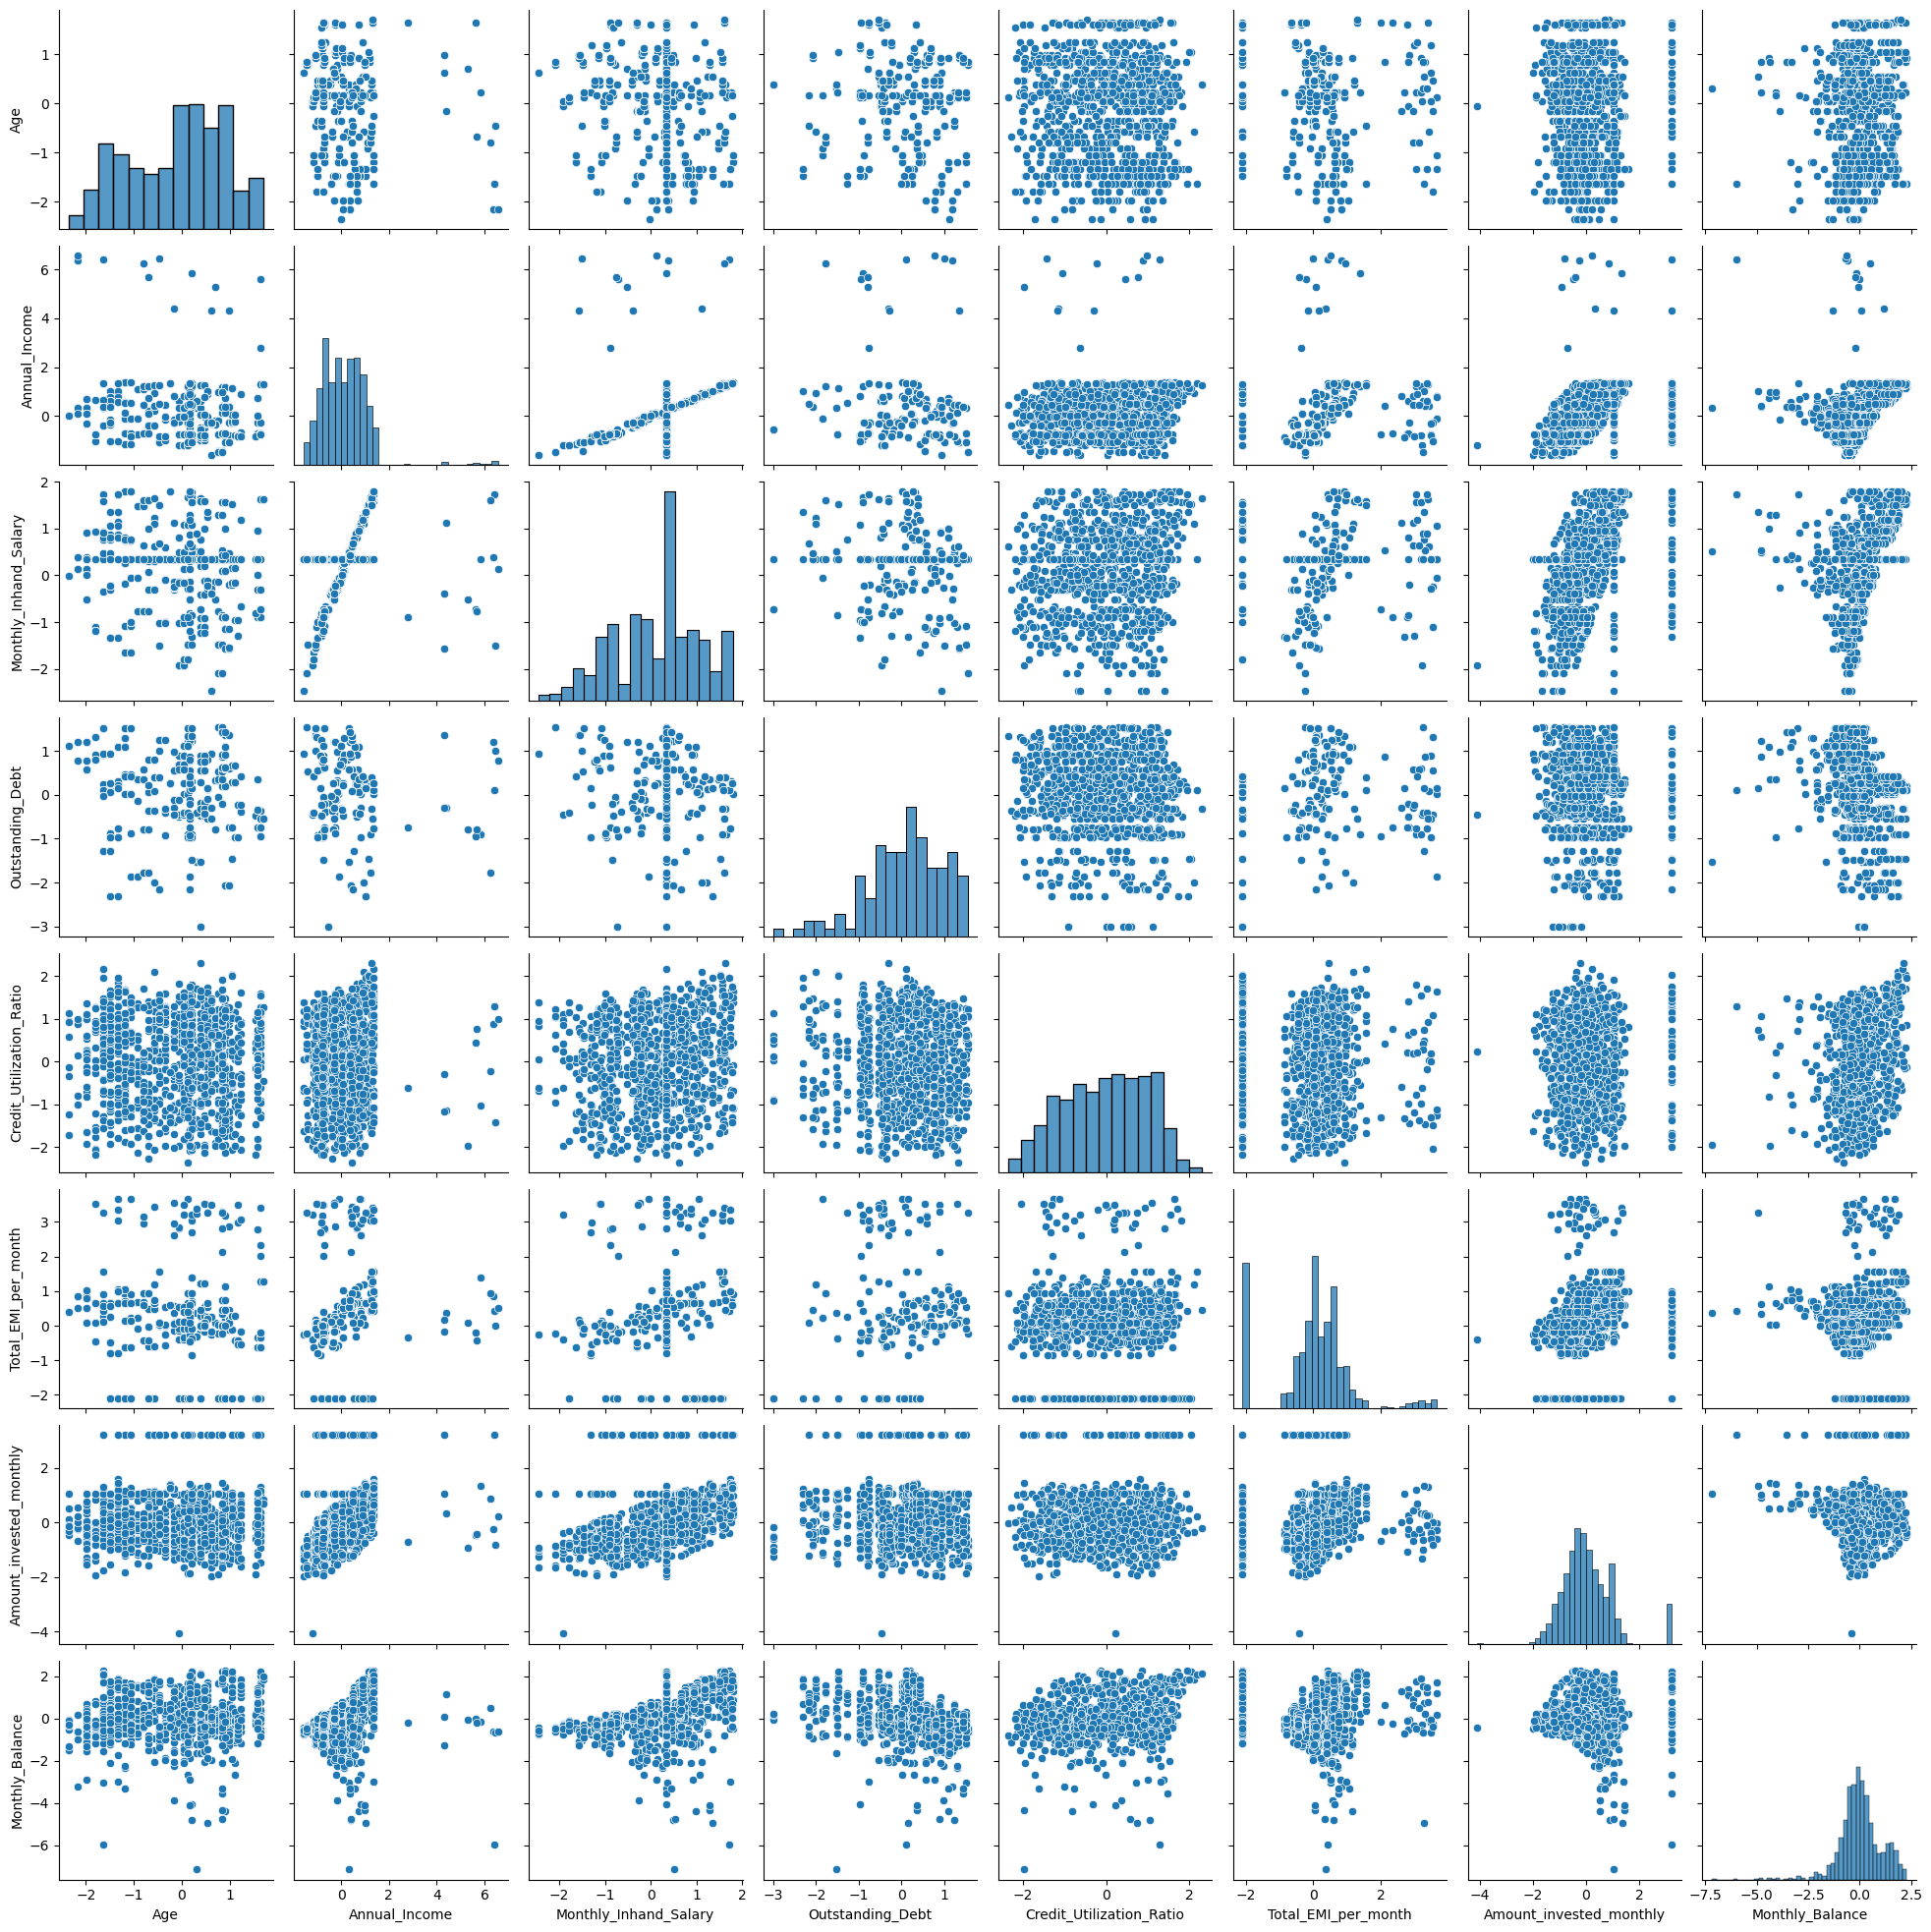

In [12]:
sns.pairplot(data.iloc[:1000])

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 8 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Age                       100000 non-null  float64
 1   Annual_Income             100000 non-null  float64
 2   Monthly_Inhand_Salary     100000 non-null  float64
 3   Outstanding_Debt          100000 non-null  float64
 4   Credit_Utilization_Ratio  100000 non-null  float64
 5   Total_EMI_per_month       100000 non-null  float64
 6   Amount_invested_monthly   100000 non-null  float64
 7   Monthly_Balance           100000 non-null  float64
dtypes: float64(8)
memory usage: 6.1 MB


In [14]:
data.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Outstanding_Debt,Credit_Utilization_Ratio,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05
mean,7.000267e-16,2.435740e-16,9.418955e-16,-4.416378e-16,3.886669e-17,5.518075e-16,5.296386e-16,1.563478e-15
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-2.357860e+00,-1.800355e+00,-3.180445e+00,-6.133186e+00,-2.867308e+00,-2.089660e+00,-4.085970e+00,-1.111367e+01
25%,-6.869141e-01,-7.418154e-01,-8.019438e-01,-4.692427e-01,-7.922724e-01,-3.354192e-01,-6.257252e-01,-5.084063e-01
50%,1.567729e-01,-5.969506e-02,2.247196e-01,1.973365e-01,8.115275e-02,7.627820e-02,-1.382740e-01,-8.687579e-02
75%,7.699460e-01,6.254989e-01,6.705581e-01,6.698660e-01,8.388449e-01,5.025975e-01,4.590525e-01,5.230187e-01
max,3.435490e+00,6.643144e+00,2.066584e+00,1.540660e+00,2.805133e+00,3.675839e+00,3.228897e+00,2.852864e+00


## Dimensionality Reductions

Define the dimensionality reduction algorithm we want to use...

In [15]:
dim_red_algorithms = {
    "pca": PCA(n_components=2),
    "kernel_pca_poly": KernelPCA(n_components=2, kernel="poly", degree=3),
    "kernel_pca_rbf": KernelPCA(n_components=2, kernel="rbf"),
    "tsne_p5": TSNE(n_components=2, perplexity=5),
    "tsne_p30": TSNE(n_components=2, perplexity=30),
    "tsne_p50": TSNE(n_components=2, perplexity=50),
    "lle_n5": LocallyLinearEmbedding(n_components=2, n_neighbors=5),
    "lle_n30": LocallyLinearEmbedding(n_components=2, n_neighbors=30),
    "lle_n50": LocallyLinearEmbedding(n_components=2, n_neighbors=50),
    "mds": MDS(n_components=2),
    "isomap_n5": Isomap(n_components=2, n_neighbors=5),
    "isomap_n30": Isomap(n_components=2, n_neighbors=30),
    "isomap_n50": Isomap(n_components=2, n_neighbors=50),
}

Define a subset of the data on which we use the embedding algorithms...

In [16]:
high_dim_points_sample = data.values[np.random.choice(len(data), size=2000, replace=False)]

Apply them to a smaller, random subset of the data...

In [17]:
low_dim_representations = dict()
for dra_key, dra in dim_red_algorithms.items():
    print(f"Performing the following algorithm: {dra_key}")
    current_dra = clone(dra)
    current_representation = current_dra.fit_transform(high_dim_points_sample)
    low_dim_representations[dra_key] = current_representation

Performing the following algorithm: pca
Performing the following algorithm: kernel_pca_poly
Performing the following algorithm: kernel_pca_rbf
Performing the following algorithm: tsne_p5
Performing the following algorithm: tsne_p30
Performing the following algorithm: tsne_p50
Performing the following algorithm: lle_n5
Performing the following algorithm: lle_n30
Performing the following algorithm: lle_n50
Performing the following algorithm: mds


/home/fazekaszs/miniforge3/envs/science/lib/python3.12/site-packages/sklearn/manifold/_mds.py:677: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9.
  warnings.warn(


Performing the following algorithm: isomap_n5
Performing the following algorithm: isomap_n30
Performing the following algorithm: isomap_n50


Plot the resulting low dimensional representations, both as a heatmap and as a scatter plot...

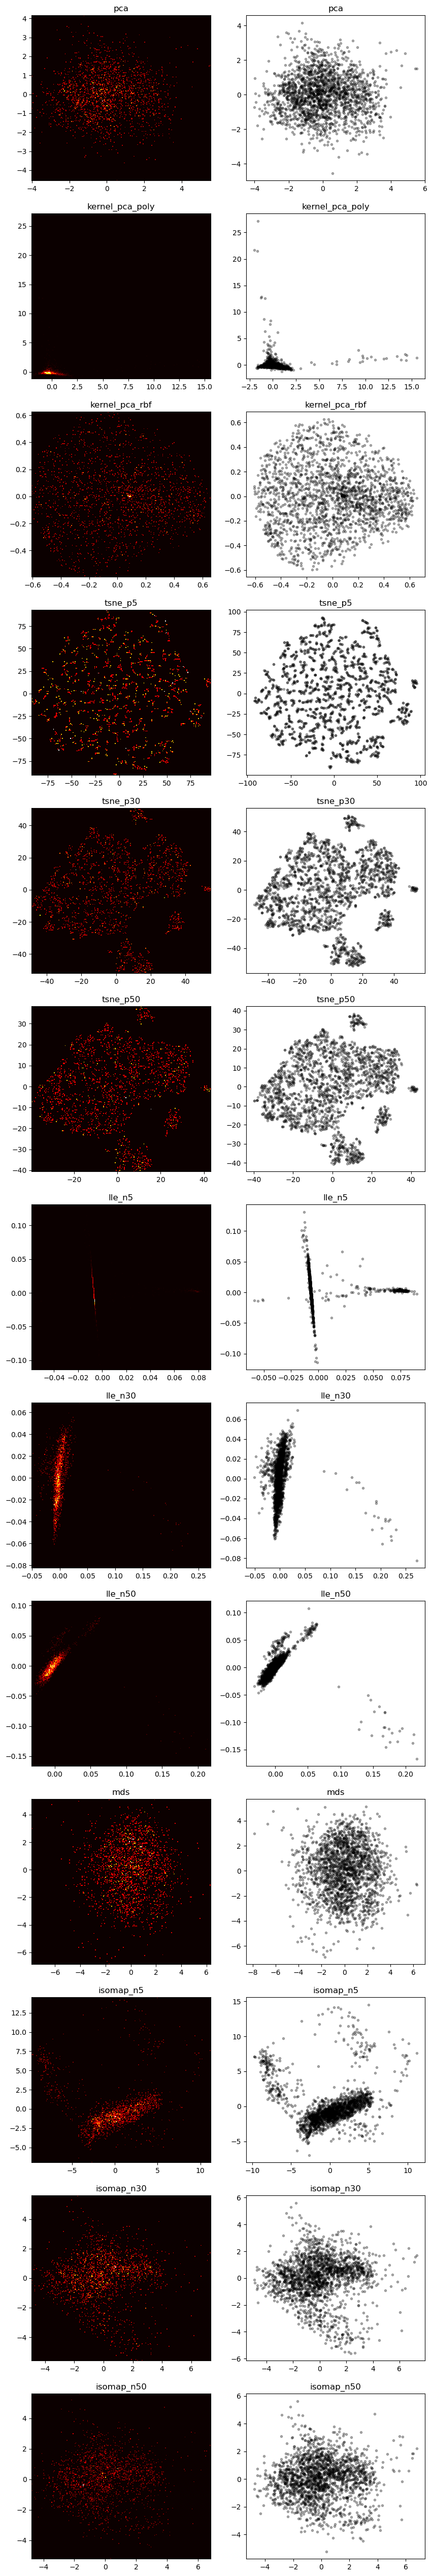

In [18]:
fig, ax = plt.subplots(len(dim_red_algorithms), 2)
fig.set_size_inches(10, 5 * len(dim_red_algorithms))

for dra_idx, (dra_key, dra_points) in enumerate(low_dim_representations.items()):
    ax[dra_idx, 0].hist2d(
        dra_points[:, 0], dra_points[:, 1], 
        bins=200, cmap="hot"
    )
    ax[dra_idx, 0].set_title(dra_key)
    ax[dra_idx, 1].scatter(
        dra_points[:, 0], dra_points[:, 1], 
        marker=".", color="black", alpha=0.3
    )
    ax[dra_idx, 1].set_title(dra_key)

## Clustering

Define the clustering algorithms...

In [19]:
clustering_algorithms = {
    "aggl_n5_ward": AgglomerativeClustering(n_clusters=5, linkage="ward"), 
    "aggl_n7_ward": AgglomerativeClustering(n_clusters=7, linkage="ward"), 
    "aggl_n5_average": AgglomerativeClustering(n_clusters=5, linkage="average"), 
    "aggl_n7_average": AgglomerativeClustering(n_clusters=7, linkage="average"), 
    "aggl_n5_complete": AgglomerativeClustering(n_clusters=5, linkage="complete"), 
    "aggl_n7_complete": AgglomerativeClustering(n_clusters=7, linkage="complete"), 
    "aggl_n5_single": AgglomerativeClustering(n_clusters=5, linkage="single"), 
    "aggl_n7_single": AgglomerativeClustering(n_clusters=7, linkage="single"), 
    "kmeans_n5": KMeans(n_clusters=5), 
    "kmeans_n7": KMeans(n_clusters=7), 
    "spectral_n5": SpectralClustering(n_clusters=5), 
    "spectral_n7": SpectralClustering(n_clusters=7), 
    "dbscan_e0.5_n5": DBSCAN(eps=0.5, min_samples=5), 
    "dbscan_e1.5_n5": DBSCAN(eps=1.5, min_samples=5), 
    "dbscan_e0.5_n10": DBSCAN(eps=0.5, min_samples=10), 
    "dbscan_e1.5_n10": DBSCAN(eps=1.5, min_samples=10), 
    "optics_n5": OPTICS(min_samples=5),
    "optics_n10": OPTICS(min_samples=10),
}

Apply clustering algorithms in high dimension...

In [20]:
high_dim_clusterings = dict()
for cla_key, cla in clustering_algorithms.items():
    print(f"Performing the following algorithm: {cla_key}")
    current_cla = clone(cla)
    current_cla.fit(high_dim_points_sample)
    high_dim_clusterings[cla_key] = current_cla.labels_

Performing the following algorithm: aggl_n5_ward
Performing the following algorithm: aggl_n7_ward
Performing the following algorithm: aggl_n5_average
Performing the following algorithm: aggl_n7_average
Performing the following algorithm: aggl_n5_complete
Performing the following algorithm: aggl_n7_complete
Performing the following algorithm: aggl_n5_single
Performing the following algorithm: aggl_n7_single
Performing the following algorithm: kmeans_n5
Performing the following algorithm: kmeans_n7
Performing the following algorithm: spectral_n5
Performing the following algorithm: spectral_n7
Performing the following algorithm: dbscan_e0.5_n5
Performing the following algorithm: dbscan_e1.5_n5
Performing the following algorithm: dbscan_e0.5_n10
Performing the following algorithm: dbscan_e1.5_n10
Performing the following algorithm: optics_n5
Performing the following algorithm: optics_n10


Apply every clustering algorithm to every embedding...

In [24]:
low_dim_clusterings = dict()
for cla_key, cla in clustering_algorithms.items():
    for dra_key, dra_points in low_dim_representations.items():

        # Spectral clustering takes forever on the current TSNE data, skipping this combination.
        if cla_key.startswith("spectral") and dra_key.startswith("tsne"):
            continue

        print(f"Performing the following algorithm: {cla_key} on {dra_key} points")
        full_key = (cla_key, dra_key)
        current_cla = clone(cla)
        current_cla.fit(dra_points)
        low_dim_clusterings[full_key] = current_cla.labels_

Performing the following algorithm: aggl_n5_ward on pca points
Performing the following algorithm: aggl_n5_ward on kernel_pca_poly points
Performing the following algorithm: aggl_n5_ward on kernel_pca_rbf points
Performing the following algorithm: aggl_n5_ward on tsne_p5 points
Performing the following algorithm: aggl_n5_ward on tsne_p30 points
Performing the following algorithm: aggl_n5_ward on tsne_p50 points
Performing the following algorithm: aggl_n5_ward on lle_n5 points
Performing the following algorithm: aggl_n5_ward on lle_n30 points
Performing the following algorithm: aggl_n5_ward on lle_n50 points
Performing the following algorithm: aggl_n5_ward on mds points
Performing the following algorithm: aggl_n5_ward on isomap_n5 points
Performing the following algorithm: aggl_n5_ward on isomap_n30 points
Performing the following algorithm: aggl_n5_ward on isomap_n50 points
Performing the following algorithm: aggl_n7_ward on pca points
Performing the following algorithm: aggl_n7_ward o

Define a function that measures the similarity between two clusterings. The similarity between two __clusters__ `A` and `B` is the number of common points, divided by the unified size of the two clusters. If a point belongs to cluster `A` in clustering 1 and cluster `B` in clustering 2, then we can assign the similarity of the two clusters to this point. The similarity between two __clusterings__ is the average value belonging to the points.

In [33]:
def clustering_similarity(labels1: np.ndarray, labels2: np.ndarray) -> float:

    # Identify the number of clusters in the two label sets.
    n_clusters1 = np.max(labels1) + 1
    n_clusters2 = np.max(labels2) + 1

    # Holds the similarity matrix of every cluster pair.
    # First index belongs to labels1, second belongs to labels2.
    cluster_similarity = np.zeros((n_clusters1, n_clusters2), dtype=float)
    for cl_idx1 in range(n_clusters1):
        for cl_idx2 in range(n_clusters2):

            mask1 = labels1 == cl_idx1
            mask2 = labels2 == cl_idx2
            common_points = np.sum(mask1 * mask2)  # * is elementwise "and", i.e. intersection
            all_points = np.sum(mask1 + mask2)  # + is elementwise "or", i.e. union
            cluster_similarity[cl_idx1, cl_idx2] = common_points / all_points

    # DBSCAN and OPTICS can produce labels of -1, which makes direct indexing
    # with labels1 and labels2 impossible.
    # If a point is deemed an outlier in either of the clusterings, it should
    # have a similarity of 0.
    outlier_mask = (labels1 == -1) + (labels2 == -1)

    # Get similarity for every non-outlier point.
    pointwise_similarities = cluster_similarity[labels1[~outlier_mask], labels2[~outlier_mask]]
    
    return float(np.sum(pointwise_similarities) / len(labels1))

Using the defined function, calculate the clustering similarities between the low dimensional and high dimensional clusterings for every clustering algorithm - embedding pair...

In [43]:
clustering_similarities = dict()
for (cla_key, dra_key), low_dim_labels in low_dim_clusterings.items():
    high_dim_labels = high_dim_clusterings[cla_key]
    clustering_similarities[(cla_key, dra_key)] = clustering_similarity(low_dim_labels, high_dim_labels)

# Convert it to a pandas DataFrame
clustering_similarities = list(clustering_similarities.items())
clustering_similarities = pd.DataFrame(data={
    "clustering_algorithm": [x[0][0] for x in clustering_similarities],
    "dim_red_algorithm": [x[0][1] for x in clustering_similarities],
    "similarity": [x[1] for x in clustering_similarities],
})
clustering_similarities.sort_values(by="similarity", inplace=True, ascending=False)

Look at the resulting table...

In [44]:
clustering_similarities

,clustering_algorithm,dim_red_algorithm,similarity
87,aggl_n5_single,mds,0.993015
90,aggl_n5_single,isomap_n50,0.992018
80,aggl_n5_single,kernel_pca_rbf,0.991023
131,spectral_n5,kernel_pca_poly,0.989567
98,aggl_n7_single,lle_n30,0.989209
...,...,...,...
179,dbscan_e0.5_n10,tsne_p5,0.000000
176,dbscan_e0.5_n10,pca,0.000000
177,dbscan_e0.5_n10,kernel_pca_poly,0.000000
186,dbscan_e0.5_n10,isomap_n5,0.000000


It would seem that using AgglomerativeClustering with n=5 and single linkage will result in a very similar clustering in high dimensions and in low dimensions, if the low dimensional representation is created using MDS. OPTICS and DBSCAN produce very different results, but this is probably due to the faulty setting of epsilon and min_samples (they should be different in low and high dimensions, if we want the same number of clusters). Let's visualize the results...

<Axes: xlabel='similarity', ylabel='Count'>

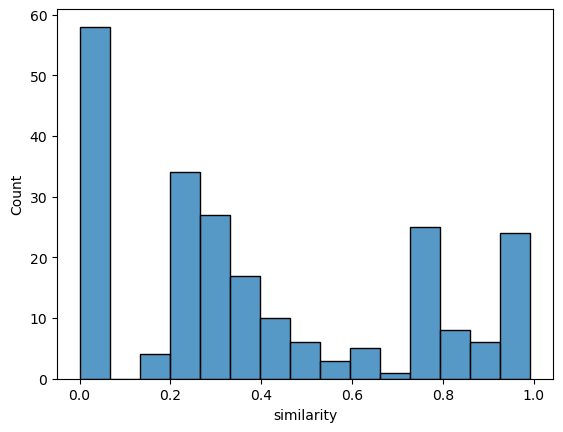

In [47]:
sns.histplot(clustering_similarities["similarity"], bins=15)

In [48]:
clustering_similarities["clustering_algorithm_name"] = clustering_similarities["clustering_algorithm"].map(lambda x: x.split("_")[0])
clustering_similarities["dim_red_algorithm_name"] = clustering_similarities["dim_red_algorithm"].map(lambda x: x.split("_")[0])

<Axes: xlabel='clustering_algorithm_name', ylabel='similarity'>

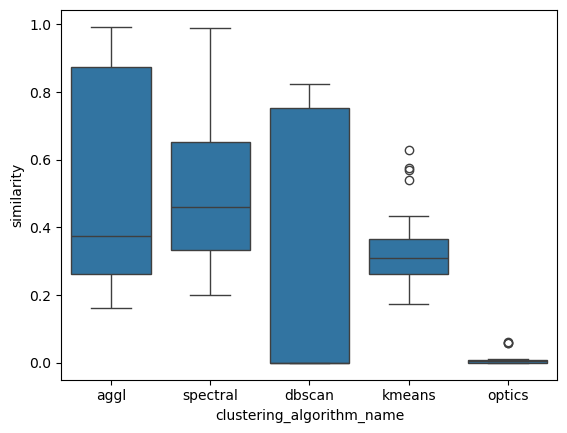

In [49]:
sns.boxplot(clustering_similarities, x="clustering_algorithm_name", y="similarity")

<Axes: xlabel='dim_red_algorithm_name', ylabel='similarity'>

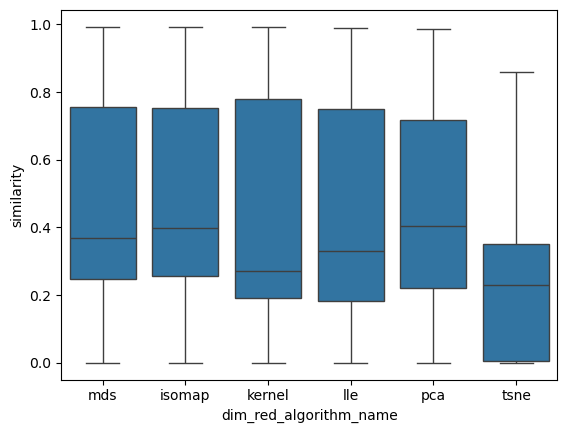

In [50]:
sns.boxplot(clustering_similarities, x="dim_red_algorithm_name", y="similarity")

Let's look at the clustering result with the highest similarity score...

Text(0.5, 1.0, 'Cl. algo.: aggl_n5_single\nDr. algo.: mds (high dim)')

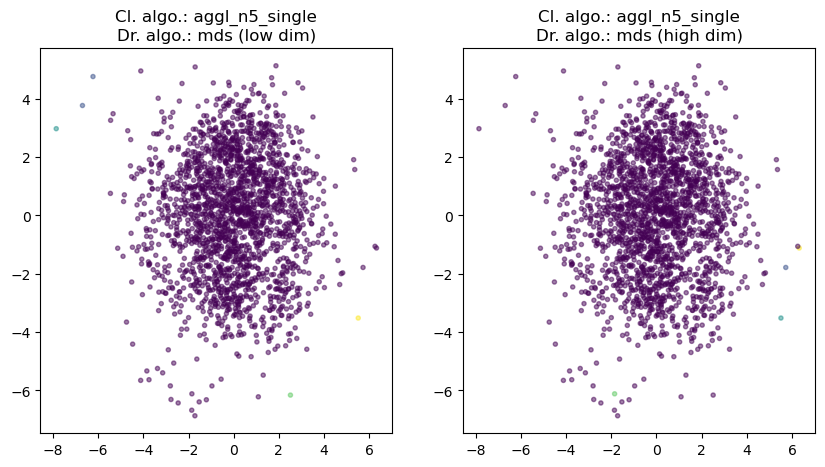

In [66]:
most_similar_cl_algo = clustering_similarities.iloc[0]["clustering_algorithm"]
most_similar_dr_algo = clustering_similarities.iloc[0]["dim_red_algorithm"]
most_similar_labels_low_dim = low_dim_clusterings[(most_similar_cl_algo, most_similar_dr_algo)]
most_similar_labels_high_dim = high_dim_clusterings[most_similar_cl_algo]
most_similar_points = low_dim_representations[most_similar_dr_algo]
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(10, 5)
ax[0].scatter(
    most_similar_points[:, 0], most_similar_points[:, 1],
    c=most_similar_labels_low_dim, alpha=0.5, marker="."
)
ax[0].set_title(f"Cl. algo.: {most_similar_cl_algo}\nDr. algo.: {most_similar_dr_algo} (low dim)")
ax[1].scatter(
    most_similar_points[:, 0], most_similar_points[:, 1],
    c=most_similar_labels_high_dim, alpha=0.5, marker="."
)
ax[1].set_title(f"Cl. algo.: {most_similar_cl_algo}\nDr. algo.: {most_similar_dr_algo} (high dim)")

This is fairly disappointing, since only a few outlier points were assigned a single cluster... Let's look at the next most similar clustering algorithm...

Text(0.5, 1.0, 'Cl. algo.: spectral_n5\nDr. algo.: kernel_pca_poly (high dim)')

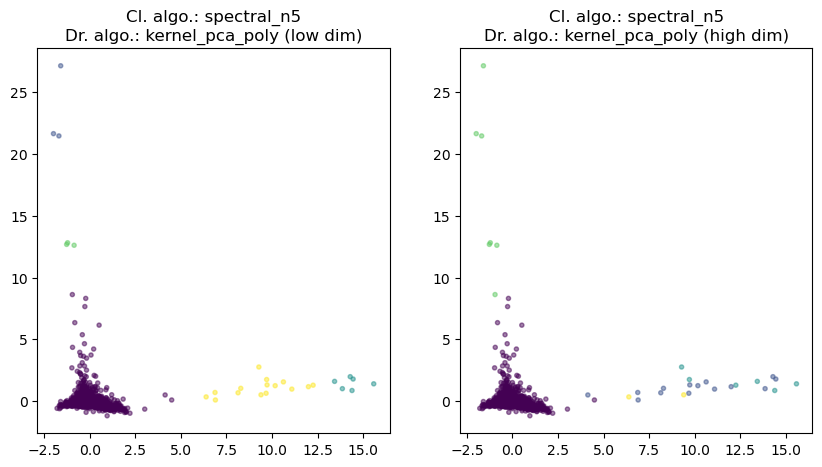

In [67]:
most_similar_cl_algo = clustering_similarities.iloc[3]["clustering_algorithm"]
most_similar_dr_algo = clustering_similarities.iloc[3]["dim_red_algorithm"]
most_similar_labels_low_dim = low_dim_clusterings[(most_similar_cl_algo, most_similar_dr_algo)]
most_similar_labels_high_dim = high_dim_clusterings[most_similar_cl_algo]
most_similar_points = low_dim_representations[most_similar_dr_algo]
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(10, 5)
ax[0].scatter(
    most_similar_points[:, 0], most_similar_points[:, 1],
    c=most_similar_labels_low_dim, alpha=0.5, marker="."
)
ax[0].set_title(f"Cl. algo.: {most_similar_cl_algo}\nDr. algo.: {most_similar_dr_algo} (low dim)")
ax[1].scatter(
    most_similar_points[:, 0], most_similar_points[:, 1],
    c=most_similar_labels_high_dim, alpha=0.5, marker="."
)
ax[1].set_title(f"Cl. algo.: {most_similar_cl_algo}\nDr. algo.: {most_similar_dr_algo} (high dim)")

This looks a bit better, but still not the most convincing. Let's look at the least similar one...

Text(0.5, 1.0, 'Cl. algo.: optics_n10\nDr. algo.: lle_n5 (high dim)')

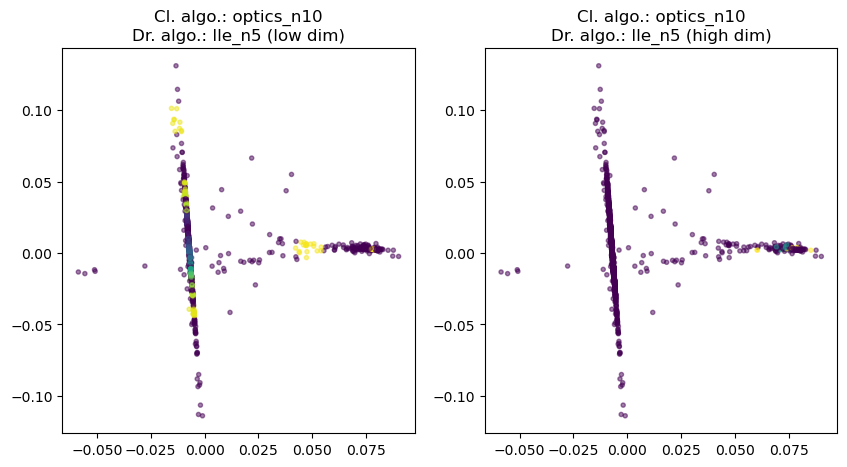

In [68]:
least_similar_cl_algo = clustering_similarities.iloc[-1]["clustering_algorithm"]
least_similar_dr_algo = clustering_similarities.iloc[-1]["dim_red_algorithm"]
least_similar_labels_low_dim = low_dim_clusterings[(least_similar_cl_algo, least_similar_dr_algo)]
least_similar_labels_high_dim = high_dim_clusterings[least_similar_cl_algo]
least_similar_points = low_dim_representations[least_similar_dr_algo]
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(10, 5)
ax[0].scatter(
    least_similar_points[:, 0], least_similar_points[:, 1],
    c=least_similar_labels_low_dim, alpha=0.5, marker="."
)
ax[0].set_title(f"Cl. algo.: {least_similar_cl_algo}\nDr. algo.: {least_similar_dr_algo} (low dim)")
ax[1].scatter(
    least_similar_points[:, 0], least_similar_points[:, 1],
    c=least_similar_labels_high_dim, alpha=0.5, marker="."
)
ax[1].set_title(f"Cl. algo.: {least_similar_cl_algo}\nDr. algo.: {least_similar_dr_algo} (high dim)")

Look at the KMeans results, since that produces fairly evenly sized clusters...

In [71]:
clustering_similarities[clustering_similarities["clustering_algorithm_name"] == "kmeans"].head()

,clustering_algorithm,dim_red_algorithm,similarity,clustering_algorithm_name,dim_red_algorithm_name
115,kmeans_n5,isomap_n30,0.628719,kmeans,isomap
113,kmeans_n5,mds,0.575388,kmeans,mds
116,kmeans_n5,isomap_n50,0.569653,kmeans,isomap
104,kmeans_n5,pca,0.539763,kmeans,pca
114,kmeans_n5,isomap_n5,0.433563,kmeans,isomap


Visualize the most similar KMeans results...

Text(0.5, 1.0, 'Cl. algo.: kmeans_n5\nDr. algo.: isomap_n30 (high dim)')

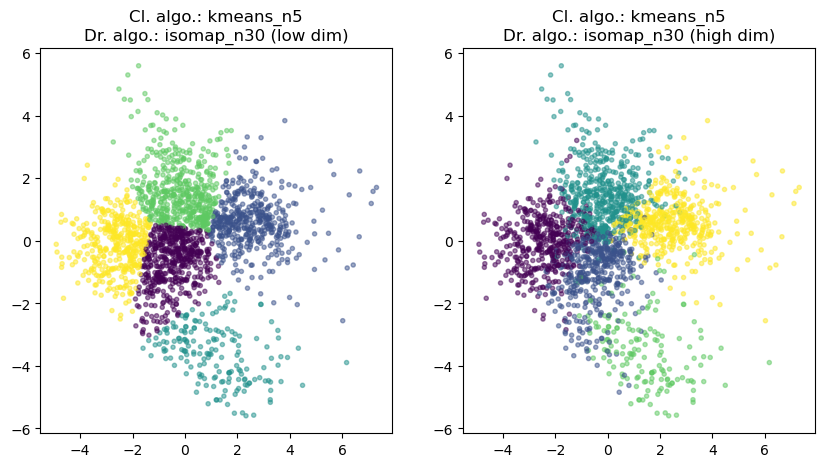

In [72]:
most_similar_labels_low_dim = low_dim_clusterings[("kmeans_n5", "isomap_n30")]
most_similar_labels_high_dim = high_dim_clusterings["kmeans_n5"]
most_similar_points = low_dim_representations["isomap_n30"]
fig, ax = plt.subplots(1, 2)
fig.set_size_inches(10, 5)
ax[0].scatter(
    most_similar_points[:, 0], most_similar_points[:, 1],
    c=most_similar_labels_low_dim, alpha=0.5, marker="."
)
ax[0].set_title(f"Cl. algo.: {"kmeans_n5"}\nDr. algo.: {"isomap_n30"} (low dim)")
ax[1].scatter(
    most_similar_points[:, 0], most_similar_points[:, 1],
    c=most_similar_labels_high_dim, alpha=0.5, marker="."
)
ax[1].set_title(f"Cl. algo.: {"kmeans_n5"}\nDr. algo.: {"isomap_n30"} (high dim)")

This looks like a good aggreement between the high dimensional and low dimensional clusterings! IsoMap creates a low dimensional representation that forces KMeans to produce almost the same clustering pattern. 

## Elbow method on the two representations

Use KMeans to extract elbow curves for the two point sets...

In [86]:
low_dim_scores, high_dim_scores = list(), list()
for n_clusters in range(2, 15):

    km_low = KMeans(n_clusters=n_clusters)
    km_low.fit(low_dim_representations["isomap_n30"])
    km_low_inertia = km_low.inertia_
    km_low_silhouette = silhouette_score(low_dim_representations["isomap_n30"], km_low.labels_)
    km_low_davies_bouldin = davies_bouldin_score(low_dim_representations["isomap_n30"], km_low.labels_)
    
    low_dim_scores.append([km_low_inertia, km_low_silhouette, km_low_davies_bouldin])
    
    km_high = KMeans(n_clusters=n_clusters)
    km_high.fit(high_dim_points_sample)
    km_high_inertia = km_high.inertia_
    km_high_silhouette = silhouette_score(high_dim_points_sample, km_high.labels_)
    km_high_davies_bouldin = davies_bouldin_score(high_dim_points_sample, km_high.labels_)
    
    high_dim_scores.append([km_high_inertia, km_high_silhouette, km_high_davies_bouldin])

low_dim_scores, high_dim_scores = np.array(low_dim_scores), np.array(high_dim_scores)

Text(0, 0.5, 'Davies-Bouldin score')

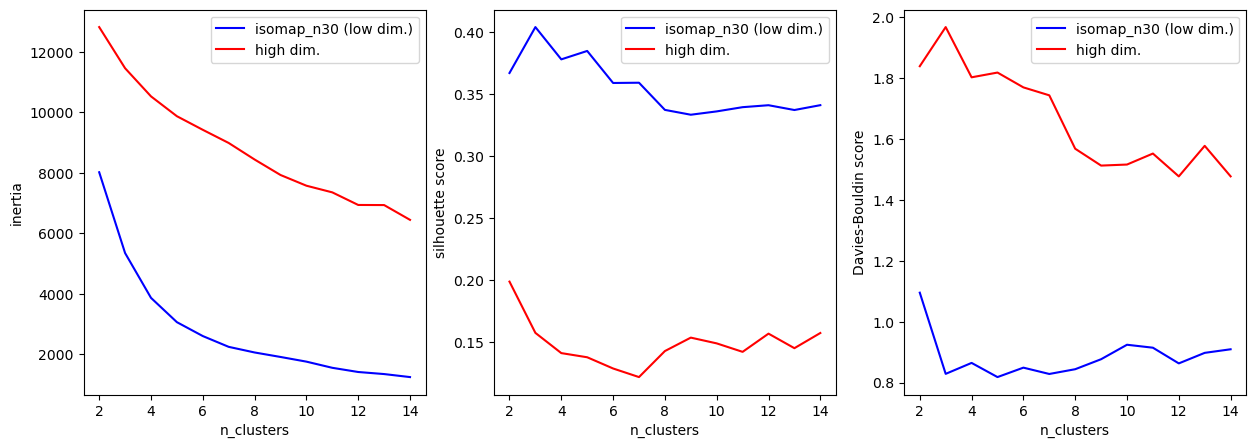

In [87]:
fig, ax = plt.subplots(1, 3)
fig.set_size_inches(15, 5)
n_dims_range = np.arange(2, 15)

ax[0].plot(n_dims_range, low_dim_scores[:, 0], color="blue", label="isomap_n30 (low dim.)")
ax[0].plot(n_dims_range, high_dim_scores[:, 0], color="red", label="high dim.")
ax[0].legend(loc="upper right")
ax[0].set_xlabel("n_clusters")
ax[0].set_ylabel("inertia")

ax[1].plot(n_dims_range, low_dim_scores[:, 1], color="blue", label="isomap_n30 (low dim.)")
ax[1].plot(n_dims_range, high_dim_scores[:, 1], color="red", label="high dim.")
ax[1].legend(loc="upper right")
ax[1].set_xlabel("n_clusters")
ax[1].set_ylabel("silhouette score")

ax[2].plot(n_dims_range, low_dim_scores[:, 2], color="blue", label="isomap_n30 (low dim.)")
ax[2].plot(n_dims_range, high_dim_scores[:, 2], color="red", label="high dim.")
ax[2].legend(loc="upper right")
ax[2].set_xlabel("n_clusters")
ax[2].set_ylabel("Davies-Bouldin score")

Interestingly, the low dimensional point set seems to have a more distinct elbow (at approx. 4) than the high dimensional point set.